# Proyecto 2: DCGAN base para personajes de Arknights y Azur Lane

Este archivo entrena **la configuración base** con pérdida BCE no saturante. Se guardan pesos,
rejillas de ruido fijo y curvas para el informe. Las pruebas de otra pérdida y de una técnica
de estabilización se harán en corridas separadas, cambiando **una sola variable a la vez**.




In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
from pathlib import Path
import csv
import json
import random
import time
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
from PIL import Image
import matplotlib.pyplot as plt

# Ajustado para Google Colab utilizando Google Drive montado
BASE_DIR = Path('/content/drive/MyDrive')
DATA_DIR = BASE_DIR / 'datos_limpios_hf'
RUN_DIR = BASE_DIR / 'resultados' / 'dcgan_base_hf_ligera'
IMAGES_DIR = DATA_DIR / 'images'
SEED = 2026
IMAGE_SIZE = 64
Z_DIM = 128
BATCH_SIZE = 8  # Conservador para memoria de GPU y RAM
EPOCHS = 50
LR = 2e-4
BETA1 = 0.5
CHECKPOINT_EVERY = 5
FLIP_HORIZONTAL = False  # Mantener fijo entre experimentos; activar solo si tiene sentido visual.

assert IMAGES_DIR.is_dir(), f'No se encontró {IMAGES_DIR}; modifica DATA_DIR y asegúrate de que exista en tu Google Drive'
assert EPOCHS > 0 and BATCH_SIZE > 0
RUN_DIR.mkdir(parents=True, exist_ok=True)
USE_CUDA = True  # Pon False si el kernel se cierra justo al iniciar CUDA.
device = torch.device('cuda' if USE_CUDA and torch.cuda.is_available() else 'cpu')
print('Dispositivo:', device, '| datos:', IMAGES_DIR)
print('PyTorch:', torch.__version__, '| CUDA incluida:', torch.version.cuda)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
if device.type != 'cuda':
    print('Aviso: entrenamiento en CPU puede tardar muchas horas; usa una GPU.')

Dispositivo: cuda | datos: /content/drive/MyDrive/datos_limpios_hf/images
PyTorch: 2.11.0+cu130 | CUDA incluida: 13.0
GPU: Tesla T4


In [6]:
print("Paso 1: Python", flush=True)
import torch
print("Paso 2: torch", torch.__version__, flush=True)

import torchvision
print("Paso 3: torchvision", torchvision.__version__, flush=True)

print("CUDA disponible:", torch.cuda.is_available(), flush=True)
print("Paso 4: comprobación CUDA", flush=True)

x = torch.ones(2, 2, device="cuda") if torch.cuda.is_available() else torch.ones(2, 2)
print("Paso 5: operación completada en", x.device, flush=True)

Paso 1: Python
Paso 2: torch 2.11.0+cu130
Paso 3: torchvision 0.26.0+cu130
CUDA disponible: True
Paso 4: comprobación CUDA
Paso 5: operación completada en cuda:0


Imágenes: 1191 | lotes/época: 149
Tamaño de muestra: (3, 64, 64) | rango: (-1.0, 1.0)


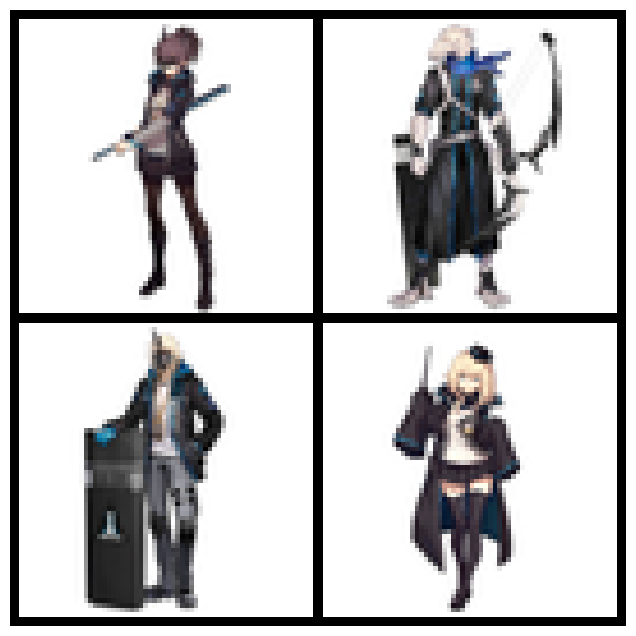

In [7]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

class CharacterDataset(Dataset):
    def __init__(self, directory, transform):
        self.paths = sorted(p for p in directory.rglob('*')
                            if p.is_file() and p.suffix.lower() in {'.png', '.jpg', '.jpeg', '.webp'})
        if not self.paths:
            raise ValueError(f'No hay imágenes en {directory}')
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        with Image.open(self.paths[index]) as img:
            return self.transform(img.convert('RGB'))

steps = [transforms.Resize((IMAGE_SIZE, IMAGE_SIZE))]
if FLIP_HORIZONTAL:
    steps.append(transforms.RandomHorizontalFlip())
steps += [transforms.ToTensor(), transforms.Normalize((0.5,) * 3, (0.5,) * 3)]
dataset = CharacterDataset(IMAGES_DIR, transforms.Compose(steps))
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                    num_workers=0, pin_memory=False, drop_last=False)  # Reduce RAM; la GPU continúa activa
assert loader.num_workers == 0, 'DataLoader antiguo: vuelve a ejecutar esta celda'
print('Imágenes:', len(dataset), '| lotes/época:', len(loader))
print('Tamaño de muestra:', tuple(dataset[0].shape), '| rango:',
      (float(dataset[0].min()), float(dataset[0].max())))

# La vista previa carga directamente las imágenes, sin procesos auxiliares.
batch = torch.stack([dataset[i] for i in range(min(4, len(dataset)))])
grid = utils.make_grid((batch + 1) / 2, nrow=2, padding=2).permute(1, 2, 0)
plt.figure(figsize=(8, 8)); plt.imshow(grid.clamp(0, 1)); plt.axis('off'); plt.show()


In [8]:
class Generator(nn.Module):
    def __init__(self, z_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 256, 4, 1, 0, bias=False), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, 4, 2, 1, bias=False), nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1, bias=False), nn.BatchNorm2d(64), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.net(x).flatten(1).squeeze(1)  # logits; sin sigmoide

def init_weights(module):
    if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(module.weight, 0.0, 0.02)
    elif isinstance(module, nn.BatchNorm2d):
        nn.init.normal_(module.weight, 1.0, 0.02)
        nn.init.zeros_(module.bias)

print('Creando modelos en', device, flush=True)
G, D = Generator(Z_DIM).to(device), Discriminator().to(device)
print('Modelos creados', flush=True)
G.apply(init_weights); D.apply(init_weights)
with torch.no_grad():
    assert G(torch.randn(2, Z_DIM, 1, 1, device=device)).shape == (2, 3, 64, 64)
with torch.no_grad():
    assert D(torch.randn(2, 3, 64, 64, device=device)).shape == (2,)
loss_fn = nn.BCEWithLogitsLoss()
opt_g = torch.optim.Adam(G.parameters(), lr=LR, betas=(BETA1, 0.999))
opt_d = torch.optim.Adam(D.parameters(), lr=LR, betas=(BETA1, 0.999))
# Generador independiente para mantener exactamente los mismos vectores de evaluación.
fixed_rng = torch.Generator(device='cpu').manual_seed(SEED + 1)
fixed_z = torch.randn(16, Z_DIM, 1, 1, generator=fixed_rng).to(device)


Creando modelos en cuda
Modelos creados


In [9]:
config = dict(seed=SEED, image_size=IMAGE_SIZE, z_dim=Z_DIM, batch_size=BATCH_SIZE,
              epochs=EPOCHS, lr=LR, beta1=BETA1, checkpoint_every=CHECKPOINT_EVERY,
              flip_horizontal=FLIP_HORIZONTAL, images=len(dataset),
              objective='BCE no saturante', source=str(IMAGES_DIR))
(RUN_DIR / 'config.json').write_text(json.dumps(config, indent=2), encoding='utf-8')
torch.save(fixed_z.cpu(), RUN_DIR / 'fixed_z.pt')

@torch.no_grad()
def save_samples(epoch):
    was_training = G.training
    G.eval()
    fake = G(fixed_z).cpu()
    utils.save_image(fake, RUN_DIR / f'fixed_epoch_{epoch:03d}.png', nrow=4,
                     normalize=True, value_range=(-1, 1))
    G.train(was_training)

def save_checkpoint(epoch, history):
    torch.save({'epoch': epoch, 'generator': G.state_dict(),
                'discriminator': D.state_dict(), 'optimizer_g': opt_g.state_dict(),
                'optimizer_d': opt_d.state_dict(), 'history': history,
                'config': config, 'fixed_z': fixed_z.cpu(),
                'rng_torch': torch.get_rng_state(),
                'rng_numpy': np.random.get_state(), 'rng_python': random.getstate(),
                'rng_cuda': torch.cuda.get_rng_state_all() if device.type == 'cuda' else None},
               RUN_DIR / 'latest.pt')
    # Evitar acumular checkpoints de gran tamaño; latest.pt se actualiza cada vez.

assert loader.num_workers == 0, 'Vuelve a ejecutar la celda que construye loader'
history = []
save_samples(0)
start = time.time()
print('Iniciando entrenamiento: lote', BATCH_SIZE, 'GPU' if device.type == 'cuda' else 'CPU', flush=True)
for epoch in range(1, EPOCHS + 1):
    G.train(); D.train()
    total_g = total_d = 0.0
    seen = 0
    for step, real in enumerate(loader):
        if step == 0:
            print(f'Época {epoch}: primer lote cargado, forma={tuple(real.shape)}', flush=True)
        real = real.to(device, non_blocking=False)
        n = real.size(0)
        if n < 2:  # BatchNorm necesita al menos dos muestras en entrenamiento.
            continue
        seen += n

        # Discriminador: minimizar BCE(D(real),1)+BCE(D(G(z)),0).
        opt_d.zero_grad(set_to_none=True)
        z = torch.randn(n, Z_DIM, 1, 1, device=device)
        fake = G(z).detach()
        d_real = D(real)
        d_fake = D(fake)
        d_loss = loss_fn(d_real, torch.ones_like(d_real)) + loss_fn(d_fake, torch.zeros_like(d_fake))
        d_loss.backward()
        opt_d.step()

        # Generador: minimizar BCE(D(G(z)),1), variante no saturante.
        opt_g.zero_grad(set_to_none=True)
        for parameter in D.parameters():
            parameter.requires_grad_(False)
        z = torch.randn(n, Z_DIM, 1, 1, device=device)
        logits = D(G(z))
        g_loss = loss_fn(logits, torch.ones_like(logits))
        g_loss.backward()
        opt_g.step()
        for parameter in D.parameters():
            parameter.requires_grad_(True)
        total_d += d_loss.item() * n
        total_g += g_loss.item() * n

    if seen == 0:
        raise ValueError('No hubo lotes con al menos dos imágenes')
    row = {'epoch': epoch, 'd_loss': total_d / seen, 'g_loss': total_g / seen}
    history.append(row)
    print(f"Época {epoch:03d}/{EPOCHS} | D={row['d_loss']:.4f} | G={row['g_loss']:.4f} | {int(time.time()-start)} s")
    if epoch == 1 or epoch % CHECKPOINT_EVERY == 0 or epoch == EPOCHS:
        save_samples(epoch)
        save_checkpoint(epoch, history)
        with (RUN_DIR / 'losses.csv').open('w', newline='', encoding='utf-8') as f:
            writer = csv.DictWriter(f, fieldnames=['epoch', 'd_loss', 'g_loss'])
            writer.writeheader(); writer.writerows(history)


Iniciando entrenamiento: lote 8 GPU
Época 1: primer lote cargado, forma=(8, 3, 64, 64)
Época 001/50 | D=0.5133 | G=5.1610 | 27 s
Época 2: primer lote cargado, forma=(8, 3, 64, 64)
Época 002/50 | D=0.6340 | G=3.5980 | 36 s
Época 3: primer lote cargado, forma=(8, 3, 64, 64)
Época 003/50 | D=0.4562 | G=4.1932 | 41 s
Época 4: primer lote cargado, forma=(8, 3, 64, 64)
Época 004/50 | D=0.5209 | G=3.7705 | 45 s
Época 5: primer lote cargado, forma=(8, 3, 64, 64)
Época 005/50 | D=0.6360 | G=3.8403 | 49 s
Época 6: primer lote cargado, forma=(8, 3, 64, 64)
Época 006/50 | D=0.6431 | G=3.9611 | 54 s
Época 7: primer lote cargado, forma=(8, 3, 64, 64)
Época 007/50 | D=0.6607 | G=3.4336 | 58 s
Época 8: primer lote cargado, forma=(8, 3, 64, 64)
Época 008/50 | D=0.6641 | G=3.3508 | 63 s
Época 9: primer lote cargado, forma=(8, 3, 64, 64)
Época 009/50 | D=0.6221 | G=3.1667 | 67 s
Época 10: primer lote cargado, forma=(8, 3, 64, 64)
Época 010/50 | D=0.5973 | G=3.2768 | 71 s
Época 11: primer lote cargado, fo

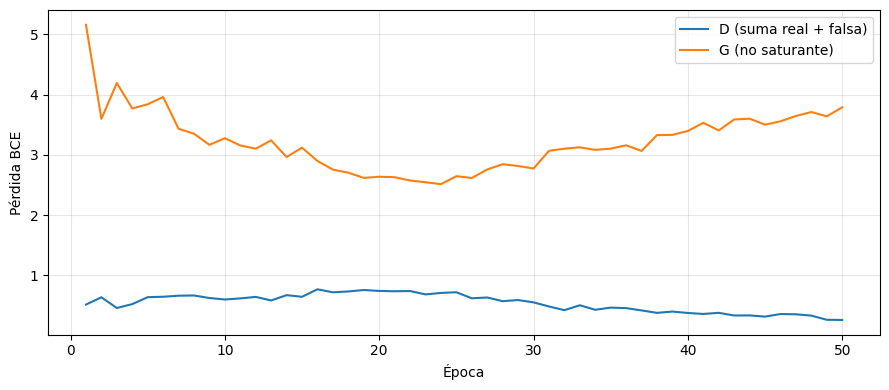

fixed_epoch_000.png


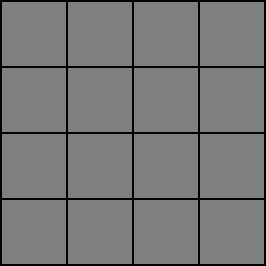

fixed_epoch_001.png


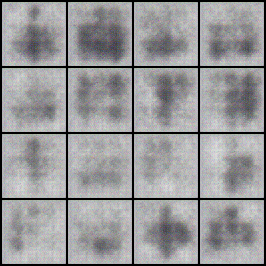

fixed_epoch_005.png


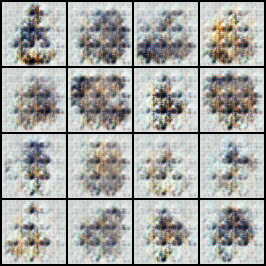

fixed_epoch_010.png


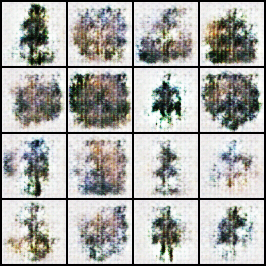

fixed_epoch_015.png


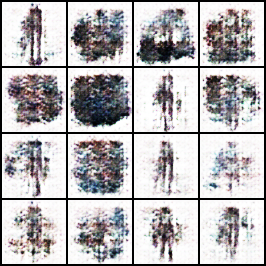

fixed_epoch_020.png


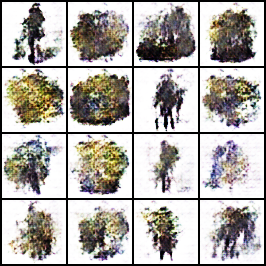

fixed_epoch_025.png


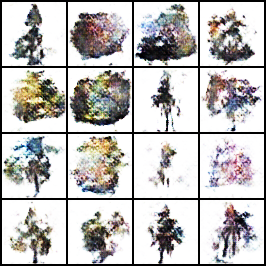

fixed_epoch_030.png


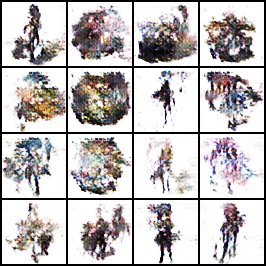

fixed_epoch_035.png


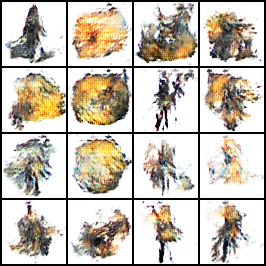

fixed_epoch_040.png


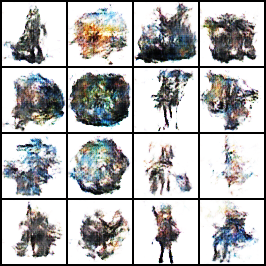

fixed_epoch_045.png


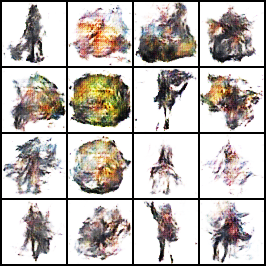

fixed_epoch_050.png


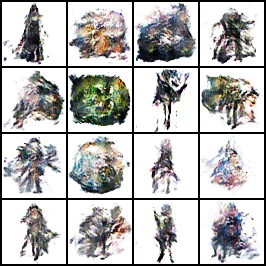

Resultados: /content/drive/MyDrive/resultados/dcgan_base_hf_ligera
Interpreta estas curvas junto con las rejillas. Una D casi nula por muchas épocas es señal de alarma.


In [10]:
epochs = [r['epoch'] for r in history]
plt.figure(figsize=(9, 4))
plt.plot(epochs, [r['d_loss'] for r in history], label='D (suma real + falsa)')
plt.plot(epochs, [r['g_loss'] for r in history], label='G (no saturante)')
plt.xlabel('Época'); plt.ylabel('Pérdida BCE'); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(RUN_DIR / 'losses.png', dpi=160); plt.show()

from IPython.display import display
sample_files = sorted(RUN_DIR.glob('fixed_epoch_*.png'))
for file in sample_files:
    print(file.name)
    display(Image.open(file))

print('Resultados:', RUN_DIR)
print('Interpreta estas curvas junto con las rejillas. Una D casi nula por muchas épocas es señal de alarma.')
